## UNet model

In [2]:
import torch
import cv2
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import transforms
from PIL import Image
os.getcwd()

'/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION'

In [3]:
image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/images/top_potsdam_3_13_RGB_2048_4096.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/masks/top_potsdam_3_13_RGB_2048_4096.png"

In [4]:
from Unet_model import UNet

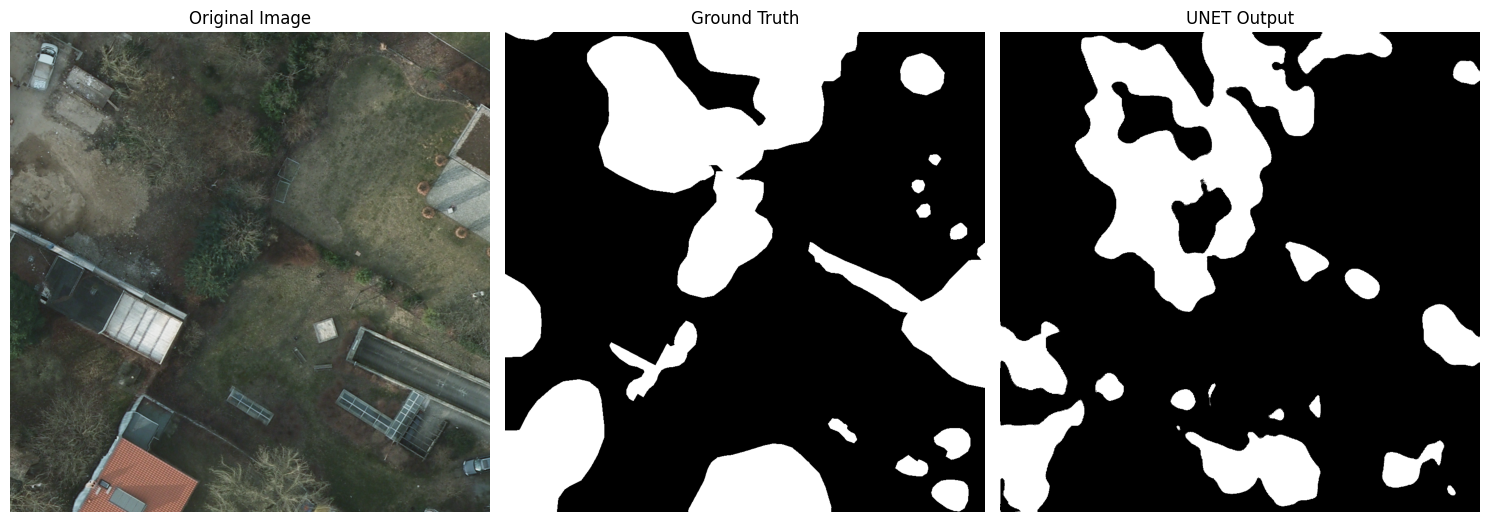

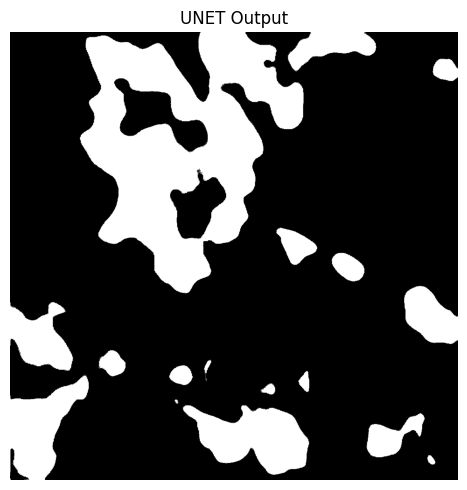

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)



my_model = UNet()
my_model.load_state_dict(torch.load("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/unet/unet_tree_50_2.pth"))
my_model.to(device=device)
my_model.eval()

with torch.no_grad():
    unet_out = my_model(image_batch)  # (1, 1, H, W)
    
    unet_mask = (unet_out > 0.5).float()

def to_numpy(t):
    return t.squeeze().detach().cpu().numpy()

original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = to_numpy(mask)
pred_mask_np = to_numpy(unet_mask) 

titles = ["Original Image", "Ground Truth","UNET Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/unet/UNET_demo_predicted_mask.png")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(pred_mask_np, cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/unet/UNET_demo_predicted_mask_only.png")
plt.show()

## DeepLabV3

In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from PIL import Image
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt

In [2]:
image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/images/top_potsdam_3_13_RGB_2048_4096.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/masks/top_potsdam_3_13_RGB_2048_4096.png"

(1, 1, 1024, 1024)


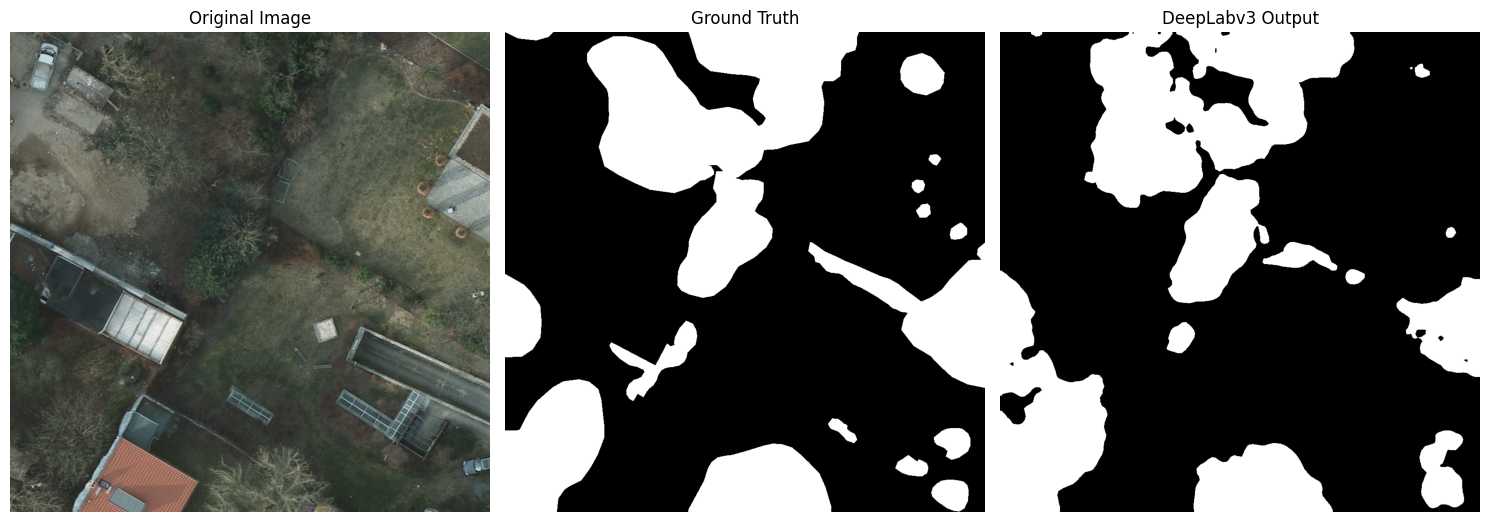

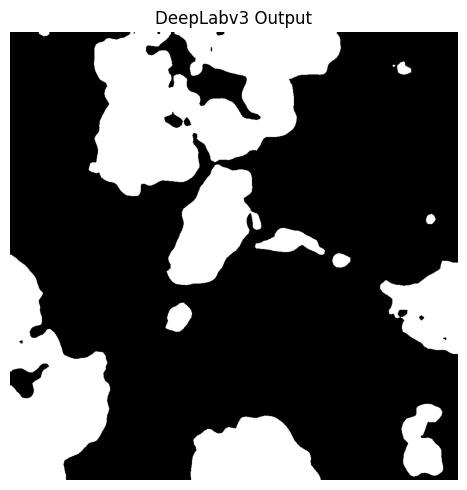

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)


model = torch.load("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/deeplabv3/deeplab_tree_full_50.pth", weights_only=False)
model.to(device)
model.eval()

with torch.no_grad():
    outputs = model(image_batch)["out"]
    preds = torch.sigmoid(outputs) > 0.5
    preds = preds.cpu().numpy().astype(np.uint8)

print(preds.shape)

original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = mask.reshape(1024,1024)
pred_mask_np = preds.reshape(1024,1024)

titles = ["Original Image", "Ground Truth","DeepLabv3 Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/deeplabv3/DEEPLABV3_demo_predicted_mask.png")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(pred_mask_np, cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/deeplabv3/DEEPLABV3_demo_predicted_mask_only.png")
plt.show()

## Mask RCNN

In [8]:
import torch
import torchvision
import torchvision.transforms as T
import os
import numpy as np
import cv2
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
import torchvision.transforms.functional as TF
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

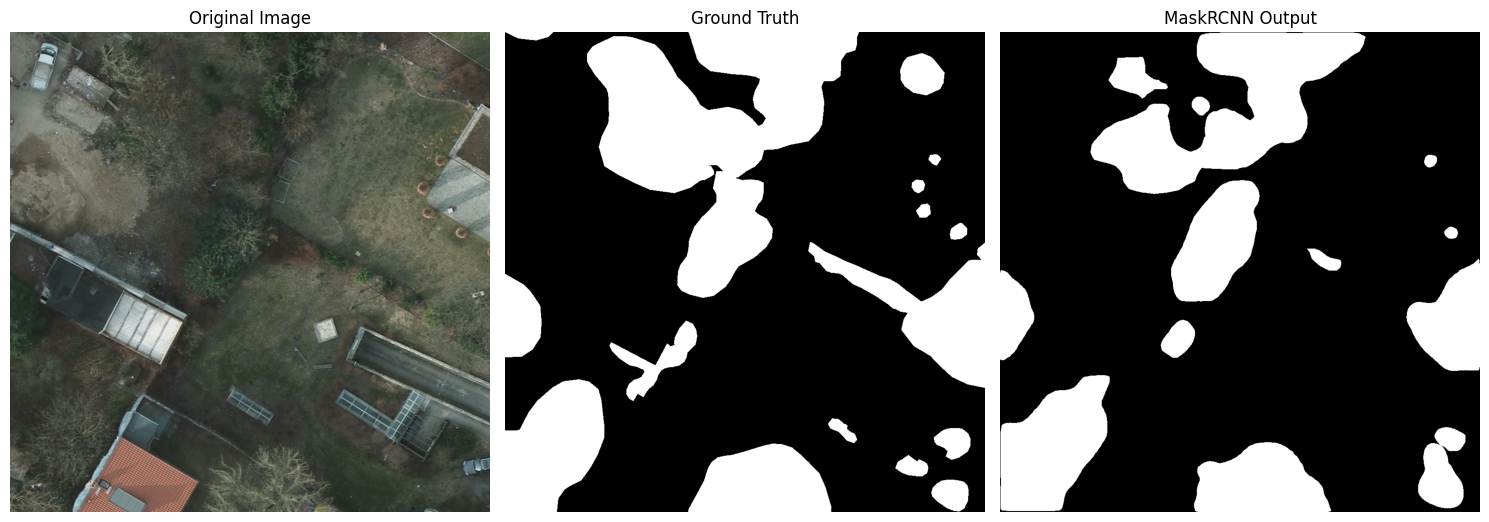

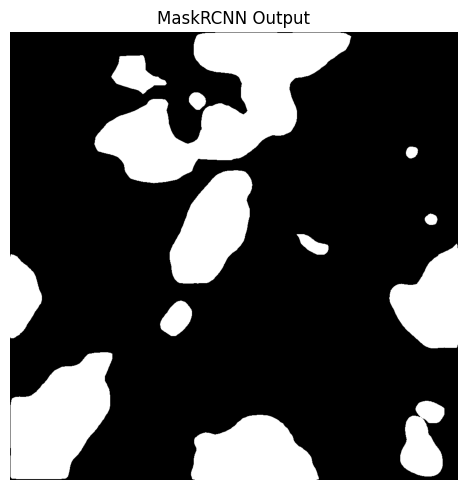

In [11]:
image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/images/top_potsdam_3_13_RGB_2048_4096.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/masks/top_potsdam_3_13_RGB_2048_4096.png"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to [0,1], shape (C, H, W)
])

image_pil = Image.open(image_path).convert("RGB")
mask_pil = Image.open(mask_path).convert("L")  # Grayscale mask

image = transform(image_pil)  # shape: (3, H, W)
mask = transform(mask_pil)    # shape: (1, H, W)
ground_mask = (mask > 0.5).float()  

image_batch = image.unsqueeze(0).to(device)  # shape: (1, 3, H, W)

model_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/maskrcnn/mask_rcnn_epoch_50_full.pth"
my_model = torch.load(model_path, weights_only=False)
my_model.to(device)
my_model.eval()


with torch.no_grad():
    output = my_model(image_batch)[0]

keep = output["scores"] >= 0.5
boxes = output["boxes"][keep].cpu().numpy()
labels = output["labels"][keep].cpu().numpy()
masks = output["masks"][keep].squeeze(1).cpu().numpy()  # Shape: (N, H, W)

final_mask = torch.zeros((1024,1024), dtype=torch.float32)

for mask in masks:
    bin_mask = (mask > 0.5).astype(np.uint8)
    bin_mask_pil = TF.to_pil_image(bin_mask)
    resized_mask = TF.to_tensor(TF.resize(bin_mask_pil, (1024,1024))).squeeze(0)
    
    # Combine using logical OR
    final_mask = torch.logical_or(final_mask, resized_mask).float()
    
    
original_np = image.permute(1, 2, 0).cpu().numpy()
gt_mask_np = ground_mask.reshape(1024,1024)
pred_mask_np = final_mask

titles = ["Original Image", "Ground Truth","MaskRCNN Output"]

images = [
    original_np,
    gt_mask_np,
    pred_mask_np
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/maskrcnn/MaskRCNN_demo_predicted_mask.png")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(pred_mask_np, cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/maskrcnn/MaskRCNN_demo_predicted_mask_only.png")
plt.show()

# YOLOv10 + SAM

In [9]:
import os
os.getcwd()
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection")

import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
from Solar_Rooftop_Detection.accuracy import compute_metrics
from Solar_Rooftop_Detection.generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt
import seaborn as sns


0: 1024x1024 2 trees, 4.9ms
Speed: 1.7ms preprocess, 4.9ms inference, 1.6ms postprocess per image at shape (1, 3, 1024, 1024)
torch.Size([1, 1024, 1024])


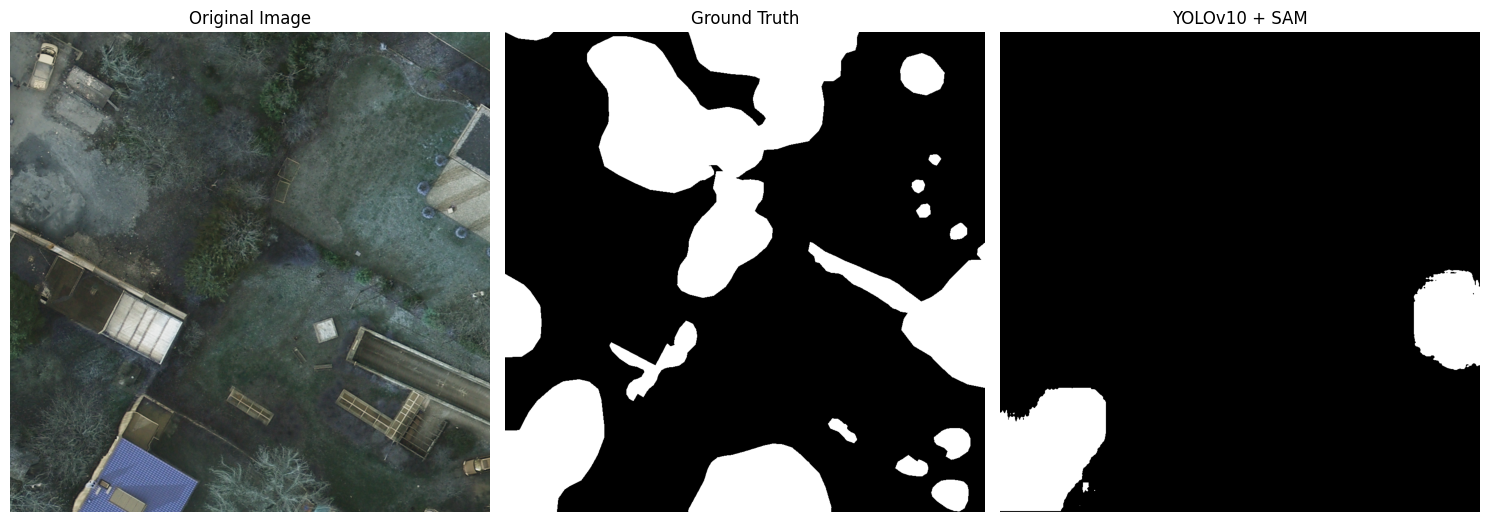

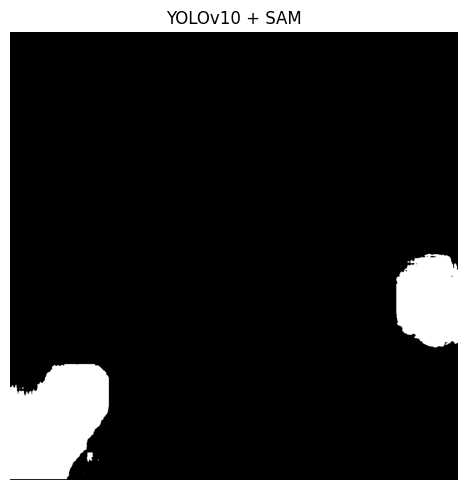

In [10]:
image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/images/top_potsdam_3_13_RGB_2048_4096.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/masks/top_potsdam_3_13_RGB_2048_4096.png"

image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

yolo_model = YOLO("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/detection/yolov10/best.pt")
sam = sam_model_registry["vit_b"]("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/sam_check_point/Final_Models/FineTune_model_0_epoch_28_02_05_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
sam_predictor
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")

print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","YOLOv10 + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/SAM/sam_yolov10_demo_predicted_mask.png")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(combined_mask.cpu().numpy()[0], cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/SAM/sam_yolov10_demo_predicted_mask_only.png")
plt.show()

# YOLOv11 + SAM


0: 1024x1024 7 trees, 3.6ms
Speed: 1.3ms preprocess, 3.6ms inference, 0.5ms postprocess per image at shape (1, 3, 1024, 1024)
torch.Size([1, 1024, 1024])


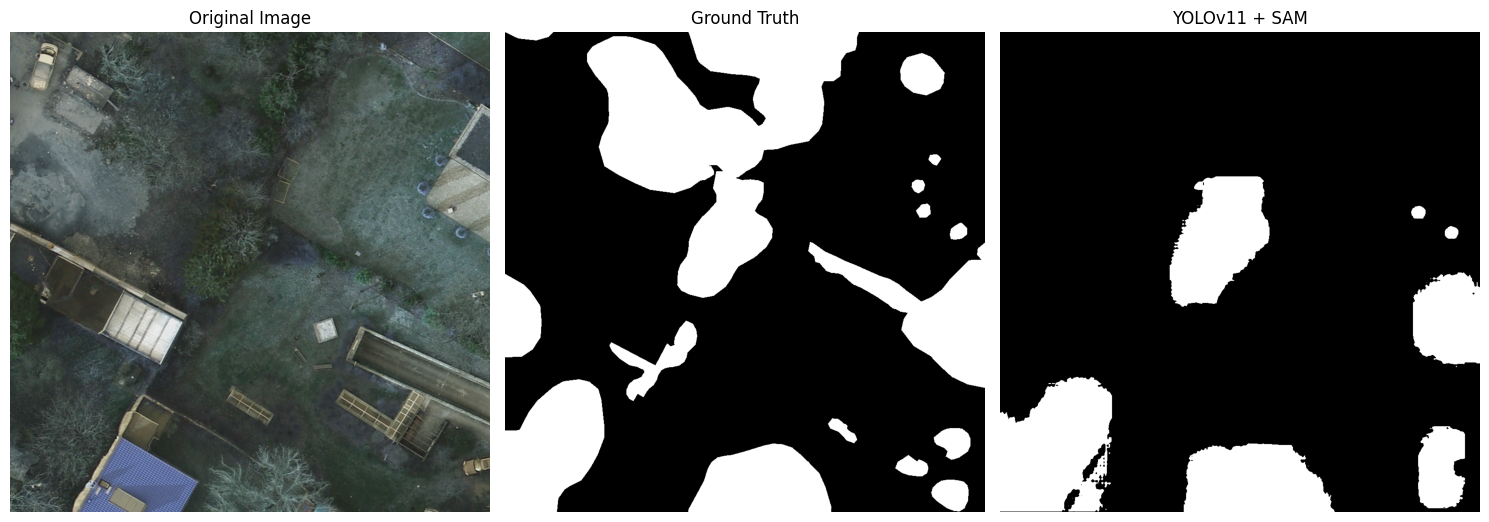

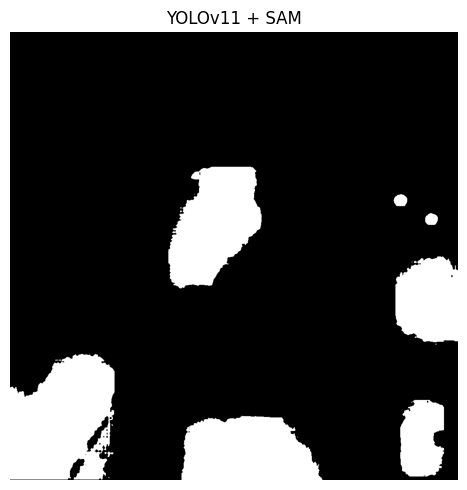

In [12]:
import os
os.getcwd()
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection")

import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
from Solar_Rooftop_Detection.accuracy import compute_metrics
from Solar_Rooftop_Detection.generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt
import seaborn as sns




image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/images/top_potsdam_3_13_RGB_2048_4096.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/masks/top_potsdam_3_13_RGB_2048_4096.png"

image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

yolo_model = YOLO("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/detection/yolov11/best.pt")
sam = sam_model_registry["vit_b"]("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/sam_check_point/Final_Models/FineTune_model_0_epoch_28_02_05_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
sam_predictor
    
yolo_results = yolo_model.predict(image, conf=0.5, device="cuda")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")

print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","YOLOv11 + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/SAM/sam_yolov11_demo_predicted_mask.png")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(combined_mask.cpu().numpy()[0], cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/SAM/sam_yolov11_demo_predicted_mask_only.png")
plt.show()

# YOLOv12 + SAM


0: 1024x1024 17 trees, 76.9ms
Speed: 1.5ms preprocess, 76.9ms inference, 0.3ms postprocess per image at shape (1, 3, 1024, 1024)
[[     403.43      876.74      708.39        1024]
 [          0      507.78       76.47      703.71]
 [          0      737.54      229.17        1024]
 [      190.6      2.9237       780.7      424.74]
 [     864.06      487.61      1023.8      748.26]
 [     182.27      1.0922      314.75       128.4]
 [     734.83      501.79      774.21      537.69]
 [     359.52      313.18      571.06       579.4]
 [     353.87      616.39      417.71      688.51]
 [     949.24      413.21      978.38      440.54]
 [     879.36      369.86      909.82      398.38]
 [     924.26      844.02      992.89      907.55]
 [     845.67      46.659      938.28      123.34]
 [     897.47      879.74      946.32      929.61]
 [     893.48      860.91      991.15      1019.5]
 [     408.54           0      759.23       229.1]
 [     867.75      317.83      898.54      348.09]]
to

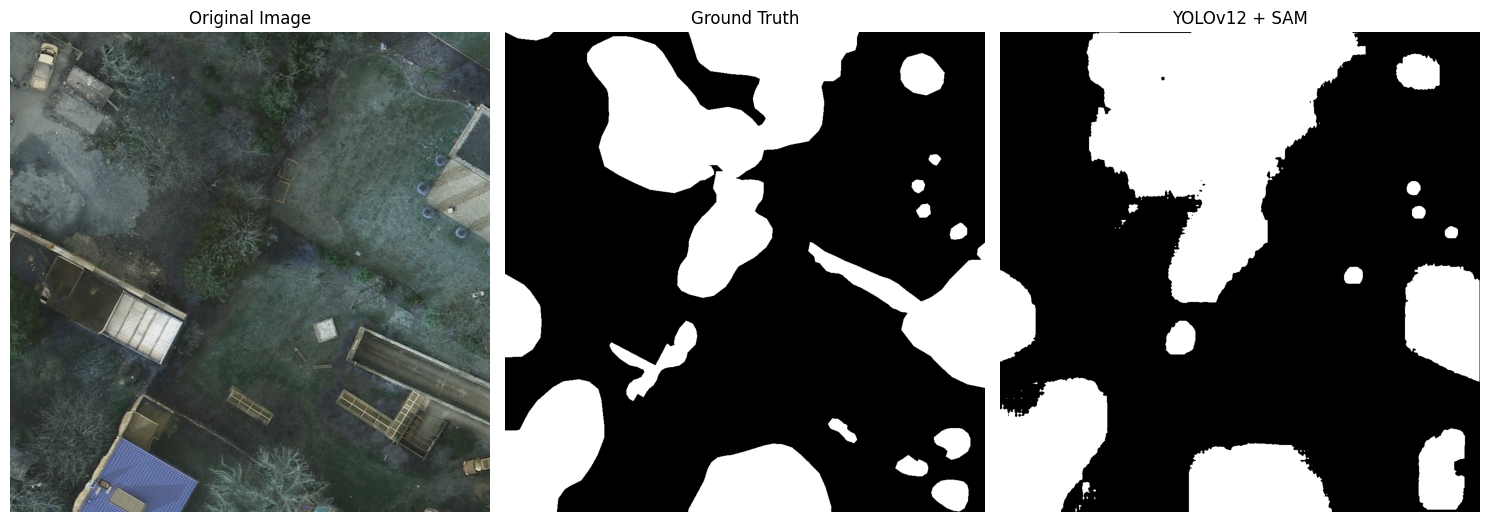

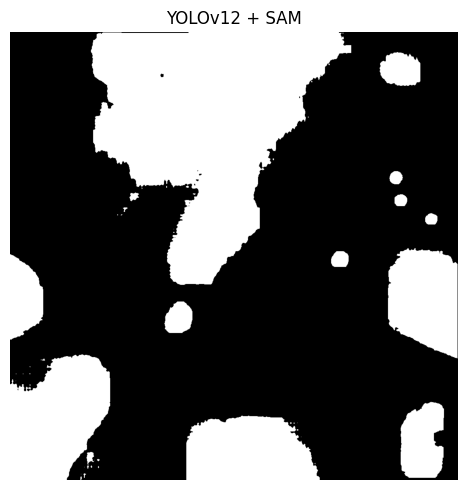

In [ ]:
import os
os.getcwd()
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection")

import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from ultralytics import YOLO
from Solar_Rooftop_Detection.accuracy import compute_metrics
from Solar_Rooftop_Detection.generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt
import seaborn as sns


image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/images/top_potsdam_3_13_RGB_2048_4096.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/masks/top_potsdam_3_13_RGB_2048_4096.png"

image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

yolo_model = YOLO("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/yolov12_tree_weights/best.pt")
sam = sam_model_registry["vit_b"]("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/sam_check_point/Final_Models/FineTune_model_0_epoch_28_02_05_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)
sam_predictor
    
yolo_results = yolo_model.predict(image, conf=0.2, device="cpu")
boxes = yolo_results[0].boxes.xyxy.cpu().numpy()
print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")

print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","YOLOv12 + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/SAM/sam_yolov12_demo_predicted_mask.png")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(combined_mask.cpu().numpy()[0], cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/SAM/sam_yolov12_demo_predicted_mask_only.png")
plt.show()

# DETR + SAM

In [1]:
import os
os.chdir("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection")


import torch
import cv2
import pandas as pd
import numpy as np
from segment_anything import SamPredictor, sam_model_registry
from Solar_Rooftop_Detection.accuracy import compute_metrics
from Solar_Rooftop_Detection.generate_isolated_masks import generate_isolated_mask
import matplotlib.pyplot as plt
import seaborn as sns
from rfdetr import RFDETRBase

2025-05-03 20:03:36.213455: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-03 20:03:36.220812: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746282816.228729  213699 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746282816.230965  213699 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746282816.237261  213699 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Loading pretrain weights


torch.Size([1, 1024, 1024])


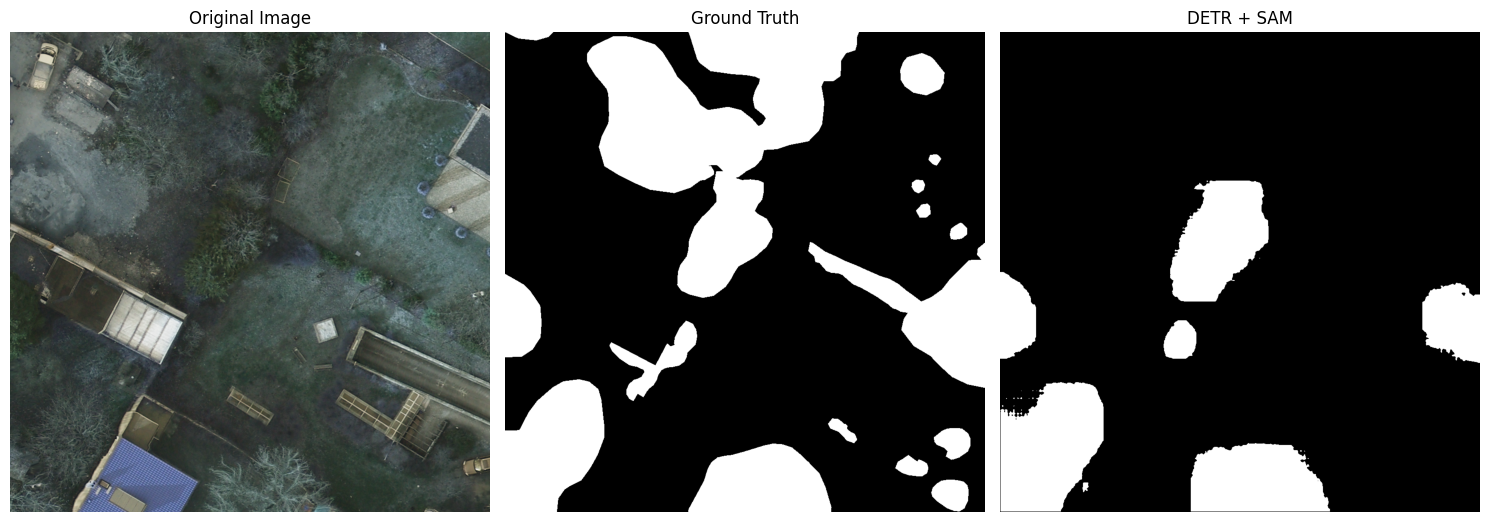

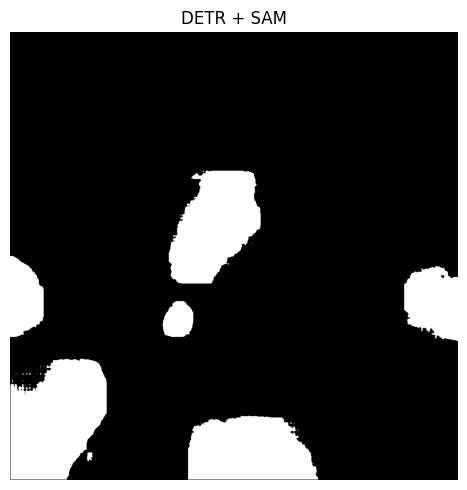

In [2]:

image_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/images/top_potsdam_3_13_RGB_2048_4096.png"
mask_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/TREE_DATASET/test/masks/top_potsdam_3_13_RGB_2048_4096.png"

image = cv2.imread(image_path)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)


checkpoint_path = "/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/detection/detr_tree.pth"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_wrapper = RFDETRBase()
underlying_model = model_wrapper.model
underlying_model.reinitialize_detection_head(num_classes=2)
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
pytorch_model = underlying_model.model
pytorch_model.load_state_dict(checkpoint['model'])

pytorch_model.to(device)
pytorch_model.eval()

sam = sam_model_registry["vit_b"]("/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/sam_check_point/Final_Models/FineTune_model_0_epoch_28_02_05_2025.pth")
sam.to("cuda")
sam_predictor = SamPredictor(sam)

detections = model_wrapper.predict(image, threshold=0.5)
boxes = detections.xyxy

# print(boxes)
gt_mask = torch.from_numpy(mask).to("cuda")
sam_predictor.set_image(image)
H, W = image.shape[:2]
# print(H, W)
# Create a combined mask with the same shape as the image
combined_mask = torch.zeros((1, H, W), dtype=torch.float32)
combined_mask = combined_mask.to("cuda")
print(combined_mask.shape)

for box in boxes:
    x1, y1, x2, y2 = map(int, box)
    
    masks, _, _ = sam_predictor.predict(box=np.array([x1, y1, x2, y2]))
    
    pred_mask = masks[0]
    pred_mask = torch.from_numpy(masks[0]).to("cuda")
    
    # print(pred_mask.shape)
    combined_mask[0, y1:y2, x1:x2] = torch.maximum(combined_mask[0, y1:y2, x1:x2], pred_mask[y1:y2, x1:x2])

titles = ["Original Image", "Ground Truth","DETR + SAM"]

images = [
    image,
    gt_mask.cpu().numpy(),
    combined_mask.cpu().numpy()[0]
]

plt.figure(figsize=(15, 10))
for i, (img, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(img, cmap='gray' if i != 0 else None)
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/SAM/sam_detr_demo_predicted_mask.png")
plt.show()

plt.figure(figsize=(5,5))
plt.imshow(combined_mask.cpu().numpy()[0], cmap='gray')
plt.title(titles[-1])
plt.axis('off')
plt.tight_layout()
plt.savefig(f"/home/dhruv/Documents/DHRUV_SOLAR_ROOFTOP/solar_github/Solar_Rooftop_Detection/TRY_ON_OTHER_DATASET/COMPARISON_WITH_TREE_SEGMENTATION/results/SAM/sam_detr_demo_predicted_mask_only.png")
plt.show()